# Sentiment Classification with Pretrained Embeddings — Stage 1

This notebook builds a binary sentiment classifier for movie reviews.

Labels:

- `0` = negative
- `1` = positive

The released training set is intentionally small and imbalanced, so the model is designed to limit overfitting while still using pretrained language representations.

## Model Structure

I use a pretrained Sentence Transformer as a frozen text encoder. Each movie review is converted into a dense sentence embedding, and a logistic regression classifier predicts the final sentiment label.

The pretrained encoder is:

`sentence-transformers/all-MiniLM-L6-v2`

I chose this structure because the training set contains only 240 reviews. Fine-tuning a much larger neural network on such a small dataset could cause overfitting. Using a frozen pretrained encoder gives the classifier language information learned from a much larger text corpus while keeping the number of trainable parameters small.

The full pipeline is:

1. movie-review text,
2. frozen pretrained sentence encoder,
3. normalized sentence embedding,
4. class-weighted logistic regression,
5. predicted label `0` or `1`.

## Handling the Small and Imbalanced Training Set

The training set contains 180 positive reviews and 60 negative reviews, so the positive class is three times larger than the negative class.

I address this in several ways:

- The pretrained encoder is kept frozen to reduce overfitting.
- Logistic regression uses `class_weight="balanced"` so mistakes on the minority class receive more weight.
- The validation split is stratified so both classes remain represented.
- I use macro F1 during model selection because it gives equal importance to both classes.
- The pretrained encoder can represent words and phrases that were not present in the released training set, which helps with unseen evaluation tokens.

## Key Training Techniques

The pretrained encoder is frozen, so it does not require neural-network fine-tuning, a neural-network optimizer, or a training learning rate.

The classifier uses:

- normalized sentence embeddings,
- logistic regression,
- `class_weight="balanced"`,
- `solver="liblinear"`,
- `max_iter=2000`,
- random seed `42`.

I compare several regularization values:

- `C = 0.1`
- `C = 1.0`
- `C = 10.0`

A stratified 25% validation split is used for model selection. The best model is selected using validation macro F1. After selecting the best value of `C`, the classifier is trained again using all 240 released training examples.

In [26]:
%pip install joblib matplotlib numpy pandas scikit-learn sentence-transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from __future__ import annotations

import json
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

TRAIN_PATH = Path("train.csv")
PUBLIC_TEST_PATH = Path("public_test.csv")
CHECKPOINT_DIR = Path("model_checkpoint")

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
ENCODING_BATCH_SIZE = 32

In [28]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Load a released CSV and validate the required columns."""
    if not path.exists():
        raise FileNotFoundError(
            f"{path} was not found. Place the released CSV beside this notebook."
        )

    data = pd.read_csv(path)

    required_columns = {"id", "text", "label"}
    missing_columns = required_columns.difference(data.columns)

    if missing_columns:
        raise ValueError(
            f"{path} is missing required columns: {sorted(missing_columns)}"
        )

    if data[["id", "text", "label"]].isna().any().any():
        raise ValueError(f"{path} contains missing id, text, or label values.")

    data = data.copy()
    data["text"] = data["text"].astype(str)
    data["label"] = data["label"].astype(int)

    labels = set(data["label"].unique())
    if not labels.issubset({0, 1}):
        raise ValueError(f"{path} contains invalid labels: {labels}")

    return data


train_df = load_dataset(TRAIN_PATH)
public_test_df = load_dataset(PUBLIC_TEST_PATH)

print("Training shape:", train_df.shape)
print("Public-test shape:", public_test_df.shape)

print("\nTraining label counts:")
print(train_df["label"].value_counts().sort_index())

print("\nPublic-test label counts:")
print(public_test_df["label"].value_counts().sort_index())

Training shape: (240, 5)
Public-test shape: (400, 5)

Training label counts:
label
0     60
1    180
Name: count, dtype: int64

Public-test label counts:
label
0    200
1    200
Name: count, dtype: int64


The expected released-data counts are:

- training set: 240 reviews,
- training labels: 60 negative and 180 positive,
- public test set: 400 reviews,
- public-test labels: 200 negative and 200 positive.

This cell is a sanity check to make sure the correct files are being used.

In [29]:
encoder = SentenceTransformer(MODEL_NAME)

train_embeddings = encoder.encode(
    train_df["text"].tolist(),
    batch_size=ENCODING_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

public_test_embeddings = encoder.encode(
    public_test_df["text"].tolist(),
    batch_size=ENCODING_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("Training embedding shape:", train_embeddings.shape)
print("Public-test embedding shape:", public_test_embeddings.shape)

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 2s [Retry 2/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 4s [Retry 3/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 8s [Retry 4/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 8s [Retry 5/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD h

Training embedding shape: (240, 384)
Public-test embedding shape: (400, 384)


In [30]:
all_indices = np.arange(len(train_df))

train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=train_df["label"].to_numpy(),
)


X_train = train_embeddings[train_indices]
y_train = train_df["label"].to_numpy()[train_indices]

X_validation = train_embeddings[validation_indices]
y_validation = train_df["label"].to_numpy()[validation_indices]

candidate_c_values = [0.1, 1.0, 10.0]
validation_results = []

for c_value in candidate_c_values:
    candidate_model = LogisticRegression(
        C=c_value,
        class_weight="balanced",
        solver="liblinear",
        max_iter=2000,
        random_state=RANDOM_SEED,
    )

    candidate_model.fit(X_train, y_train)

    validation_predictions = candidate_model.predict(X_validation)

    validation_accuracy = accuracy_score(
        y_validation,
        validation_predictions,
    )

    validation_macro_f1 = f1_score(
        y_validation,
        validation_predictions,
        average="macro",
    )

    validation_results.append(
        {
            "C": c_value,
            "validation_accuracy": validation_accuracy,
            "validation_macro_f1": validation_macro_f1,
        }
    )

validation_results_df = pd.DataFrame(validation_results)
validation_results_df

,C,validation_accuracy,validation_macro_f1
0,0.1,0.566667,0.541716
1,1.0,0.683333,0.639126
2,10.0,0.650000,0.589710


In [31]:
best_row = validation_results_df.sort_values(
    by=["validation_macro_f1", "validation_accuracy", "C"],
    ascending=[False, False, True],
).iloc[0]

best_c = float(best_row["C"])

print(f"Selected C: {best_c}")
print(
    f"Validation macro F1: "
    f"{float(best_row['validation_macro_f1']):.4f}"
)
print(
    f"Validation accuracy: "
    f"{float(best_row['validation_accuracy']):.4f}"
)

Selected C: 1.0
Validation macro F1: 0.6391
Validation accuracy: 0.6833


In [32]:
final_classifier = LogisticRegression(
    C=best_c,
    class_weight="balanced",
    solver="liblinear",
    max_iter=2000,
    random_state=RANDOM_SEED,
)

final_classifier.fit(
    train_embeddings,
    train_df["label"].to_numpy(),
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `

In [33]:
public_predictions = final_classifier.predict(
    public_test_embeddings
).astype(int)

public_accuracy = accuracy_score(
    public_test_df["label"].to_numpy(),
    public_predictions,
)

public_confusion_matrix = confusion_matrix(
    public_test_df["label"].to_numpy(),
    public_predictions,
    labels=[0, 1],
)

print(f"Public-test accuracy: {public_accuracy:.4f}")

print("\nClassification report:")
print(
    classification_report(
        public_test_df["label"].to_numpy(),
        public_predictions,
        labels=[0, 1],
        target_names=["negative", "positive"],
        digits=4,
    )
)

print("Confusion matrix:")
print(public_confusion_matrix)

Public-test accuracy: 0.6000

Classification report:
              precision    recall  f1-score   support

    negative     0.6124    0.5450    0.5767       200
    positive     0.5901    0.6550    0.6209       200

    accuracy                         0.6000       400
   macro avg     0.6012    0.6000    0.5988       400
weighted avg     0.6012    0.6000    0.5988       400

Confusion matrix:
[[109  91]
 [ 69 131]]


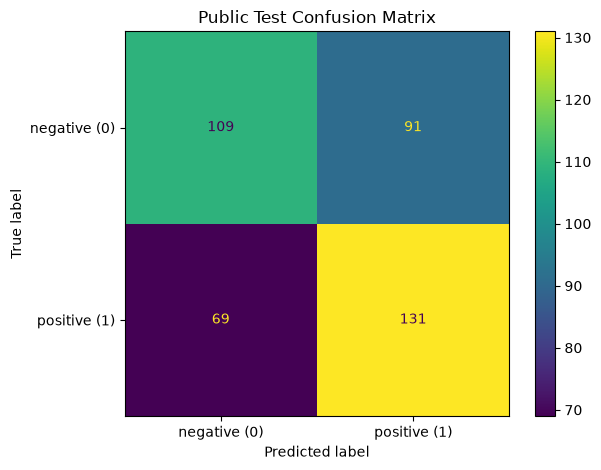

In [34]:
display = ConfusionMatrixDisplay(
    confusion_matrix=public_confusion_matrix,
    display_labels=["negative (0)", "positive (1)"],
)

display.plot(values_format="d")

plt.title("Public Test Confusion Matrix")
plt.tight_layout()
plt.show()

## Evaluation Result

The cells above report the required total public-test accuracy and confusion matrix.

In the confusion matrix:

- rows are the true labels,
- columns are the predicted labels,
- class `0` is negative,
- class `1` is positive.

I also report precision, recall, and F1 for each class so I can check whether the classifier performs reasonably on both classes instead of relying only on total accuracy.

In [35]:
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

embedding_model_dir = CHECKPOINT_DIR / "embedding_model"

encoder.save(str(embedding_model_dir))

joblib.dump(
    final_classifier,
    CHECKPOINT_DIR / "classifier.joblib",
)

metadata = {
    "model_name": MODEL_NAME,
    "encoding_batch_size": ENCODING_BATCH_SIZE,
    "selected_C": best_c,
    "class_weight": "balanced",
    "solver": "liblinear",
    "max_iter": 2000,
    "random_seed": RANDOM_SEED,
    "normalize_embeddings": True,
    "label_mapping": {
        "0": "negative",
        "1": "positive",
    },
}

with (CHECKPOINT_DIR / "metadata.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(metadata, file, indent=2)

print("Saved checkpoint to:", CHECKPOINT_DIR.resolve())

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.98it/s]

Saved checkpoint to: C:\Users\tiffy\Downloads\sentiment_stage1_pretrained_embeddings\sentiment_stage1_pretrained_embeddings\model_checkpoint


In [36]:
public_test_predictions = pd.DataFrame(
    {
        "id": public_test_df["id"].to_numpy(),
        "predicted_label": public_predictions,
    }
)

public_test_predictions.to_csv(
    "public_test_predictions.csv",
    index=False,
)

print(public_test_predictions.head())
print("\nColumns:", public_test_predictions.columns.tolist())
print("Rows:", len(public_test_predictions))
print(
    "Unique predicted labels:",
    sorted(public_test_predictions["predicted_label"].unique().tolist()),
)

                id  predicted_label
0  pos_cv696_29740                1
1  pos_cv669_22995                1
2   neg_cv963_7208                0
3   pos_cv182_7281                1
4  pos_cv162_10424                0

Columns: ['id', 'predicted_label']
Rows: 400
Unique predicted labels: [0, 1]


The generated `public_test_predictions.csv` contains exactly:

```text
id,predicted_label
```

where each predicted label is either `0` or `1`.

In [37]:
reloaded_encoder = SentenceTransformer(
    str(CHECKPOINT_DIR / "embedding_model")
)

reloaded_classifier = joblib.load(
    CHECKPOINT_DIR / "classifier.joblib"
)

with (CHECKPOINT_DIR / "metadata.json").open(
    "r",
    encoding="utf-8",
) as file:
    reloaded_metadata = json.load(file)

reloaded_embeddings = reloaded_encoder.encode(
    public_test_df["text"].tolist(),
    batch_size=int(
        reloaded_metadata["encoding_batch_size"]
    ),
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

reloaded_predictions = reloaded_classifier.predict(
    reloaded_embeddings
).astype(int)

assert np.array_equal(
    public_predictions,
    reloaded_predictions,
)

print("Checkpoint reload test passed.")
print(
    "Reloaded predictions exactly match "
    "the original public-test predictions."
)

Batches: 100%|██████████| 13/13 [00:17<00:00,  1.37s/it]

Checkpoint reload test passed.
Reloaded predictions exactly match the original public-test predictions.


## Final Design Summary

The final model combines pretrained neural language representations with a small class-weighted classifier.

The frozen pretrained encoder helps reduce overfitting on the small training set and provides representations for words and phrases that may not appear in the released training data. Balanced class weights address the 180/60 class imbalance, and a stratified validation split is used to compare regularization settings.

The saved checkpoint contains both the pretrained encoder and fitted classifier. The reload test confirms that the checkpoint can generate the same predictions without retraining.

## Use of AI

I used generative AI tools to help with debugging, code organization, and checking that my implementation followed the assignment requirements. I also used AI to help troubleshoot Python environment and package installation issues and to review my approach for handling the small and imbalanced training set.

I ran and verified the code myself using the provided datasets. The reported accuracy, confusion matrix, predictions, and saved model checkpoint were generated by the executed notebook. I did not use AI to manually label, rewrite, or modify any of the training or test examples.